# Member Services Operations Dashboard (credit union support center)

**Audience:** member-services managers who need a weekly view of whether tickets are resolved within SLA, where the
bottlenecks are, and whether slow service is hurting member satisfaction.

**Pipeline:** synthetic raw tables → cleaned, enriched ticket table (silver) → SQL views (gold) → KPI tiles, charts, and CSV marts
for Power BI / Tableau. Written in PySpark + Spark SQL, so it runs unchanged on Databricks or locally.

**About the data.** The data is synthetic. The generator (next cell) builds in realistic operating patterns: slower email handling,
a Monday backlog, newer agents taking longer, and lower CSAT after SLA breaches. So the dashboard shows what it is designed to catch.
The point of the project is the modeling, metric definitions and dashboard design, not the findings themselves.

In [1]:
import os, math, random
from datetime import datetime, timedelta
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pyspark.sql import SparkSession, functions as F

spark = SparkSession.builder.appName("MemberServicesDashboard").master("local[2]").config("spark.ui.enabled", "false").config("spark.ui.showConsoleProgress", "false").getOrCreate() \
    if "DATABRICKS_RUNTIME_VERSION" not in os.environ else SparkSession.builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
sns.set_theme(style="whitegrid")
TEAM_COLORS = {"East": "#4C72B0", "West": "#DD8452", "Central": "#55A868"}
random.seed(42)

## 1. Generate raw tables
Documented assumptions: 25 agents across three teams; 26 weeks of tickets (Jan–Jun 2024) with a Monday surge;
channel mix phone 45% / chat 35% / email 20%; resolution time lognormal around a channel baseline, scaled by priority, agent tenure
and weekday load; ~30% of members answer the CSAT survey, with lower ratings when the SLA is breached.

In [2]:
SLA_MIN = {"High": 60, "Medium": 240, "Low": 1440}
PERIOD_START, WEEKS = datetime(2024, 1, 1), 26
PERIOD_END = PERIOD_START + timedelta(weeks=WEEKS)

agents = []
for i in range(25):
    hire = datetime(2019, 1, 1) + timedelta(days=int(random.uniform(0, 1900)))
    agents.append((f"A{100+i}", f"Agent_{i:02d}", random.choice(["East", "West", "Central"]), hire.date().isoformat()))
agents_df = spark.createDataFrame(agents, ["agent_id", "agent_name", "team", "hire_date"])

members = [(f"M{1000+i}", random.randint(18, 80), random.choice(["CA", "NY", "TX", "FL", "IL", "WA"])) for i in range(1500)]
members_df = spark.createDataFrame(members, ["member_id", "age", "state"])

tenure = {a[0]: (PERIOD_END - datetime.fromisoformat(a[3])).days / 30.4 for a in agents}
CHANNEL_BASE = {"Chat": 25, "Phone": 40, "Email": 300}
PRIORITY_MULT = {"High": 0.6, "Medium": 1.0, "Low": 1.8}
tickets, surveys = [], []
for d in range(WEEKS * 7):
    day = PERIOD_START + timedelta(days=d)
    wd = day.weekday()
    n = int(random.gauss({0: 60, 1: 45, 2: 42, 3: 42, 4: 40, 5: 18, 6: 12}[wd], 5))
    for _ in range(max(n, 0)):
        created = day + timedelta(hours=random.choice(range(8, 20)), minutes=random.randint(0, 59))
        channel = random.choices(["Phone", "Chat", "Email"], [45, 35, 20])[0]
        priority = random.choices(["High", "Medium", "Low"], [15, 45, 40])[0]
        agent = random.choice(agents)[0]
        load = 1.35 if wd == 0 else 1.0
        experience = 1.4 if tenure[agent] < 12 else (1.15 if tenure[agent] < 24 else 1.0)
        mins = max(3, random.lognormvariate(math.log(CHANNEL_BASE[channel] * PRIORITY_MULT[priority] * load * experience), 0.6))
        tid = f"T{len(tickets)+100000}"
        tickets.append((tid, created, created + timedelta(minutes=mins), channel, agent, random.choice(members)[0], priority))
        if random.random() < 0.30:
            breached = mins > SLA_MIN[priority]
            rating = min(5, max(1, round(random.gauss(3.1 if breached else 4.3, 0.9))))
            surveys.append((tid, rating))

tickets_df = spark.createDataFrame(tickets, ["ticket_id", "created_at", "closed_at", "channel", "agent_id", "member_id", "priority"])
surveys_df = spark.createDataFrame(surveys, ["ticket_id", "csat_rating"])
print(f"agents {agents_df.count()}, members {members_df.count()}, tickets {tickets_df.count():,}, surveys {surveys_df.count():,}")

agents 25, members 1500, tickets 6,723, surveys 2,019


## 2. Silver: one enriched row per ticket

In [3]:
sla_map = F.create_map(*[x for k, v in SLA_MIN.items() for x in (F.lit(k), F.lit(v))])
dashboard_df = (tickets_df
    .withColumn("resolution_min", (F.unix_timestamp("closed_at") - F.unix_timestamp("created_at")) / 60)
    .withColumn("sla_target_min", sla_map[F.col("priority")])
    .withColumn("sla_met", (F.col("resolution_min") <= F.col("sla_target_min")).cast("int"))
    .join(agents_df, "agent_id", "left")
    .withColumn("tenure_months", F.round(F.months_between(F.lit(PERIOD_END.date().isoformat()), F.col("hire_date")), 0).cast("int"))
    .join(surveys_df, "ticket_id", "left"))
dashboard_df.createOrReplaceTempView("dashboard_data")
assert dashboard_df.count() == tickets_df.count(), "joins must not duplicate tickets"
assert dashboard_df.filter("resolution_min < 0").count() == 0
dashboard_df.select("ticket_id", "channel", "priority", "resolution_min", "sla_target_min", "sla_met", "team", "tenure_months", "csat_rating").show(5)

+---------+-------+--------+------------------+--------------+-------+-------+-------------+-----------+
|ticket_id|channel|priority|    resolution_min|sla_target_min|sla_met|   team|tenure_months|csat_rating|
+---------+-------+--------+------------------+--------------+-------+-------+-------------+-----------+
|  T100005|   Chat|    High|              22.1|            60|      1|   East|           32|       NULL|
|  T100003|  Email|  Medium| 571.2333333333333|           240|      0|Central|           20|       NULL|
|  T100001|   Chat|  Medium|57.833333333333336|           240|      1|   West|           58|          3|
|  T100004|  Email|  Medium|111.88333333333334|           240|      1|   East|           29|       NULL|
|  T100000|  Phone|  Medium|31.533333333333335|           240|      1|   East|           49|          5|
+---------+-------+--------+------------------+--------------+-------+-------+-------------+-----------+
only showing top 5 rows



## 3. Gold: SQL views behind each dashboard tile (`sql/gold_views.sql`)

In [4]:
for stmt in open("sql/gold_views.sql").read().split(";"):
    if "CREATE" in stmt:
        spark.sql(stmt)
gold = {v: spark.table(v).toPandas() for v in ["kpi_summary", "weekly_team", "sla_by_channel_priority", "weekday_load", "agent_scorecard", "csat_by_sla"]}
for name, pdf in gold.items(): pdf.to_csv(f"marts/{name}.csv", index=False)
display(gold["kpi_summary"])

,tickets,sla_compliance_pct,median_resolution_min,avg_csat,survey_response_pct
0,6723,88.6,57.0,4.09,30.0


## 4. Dashboard

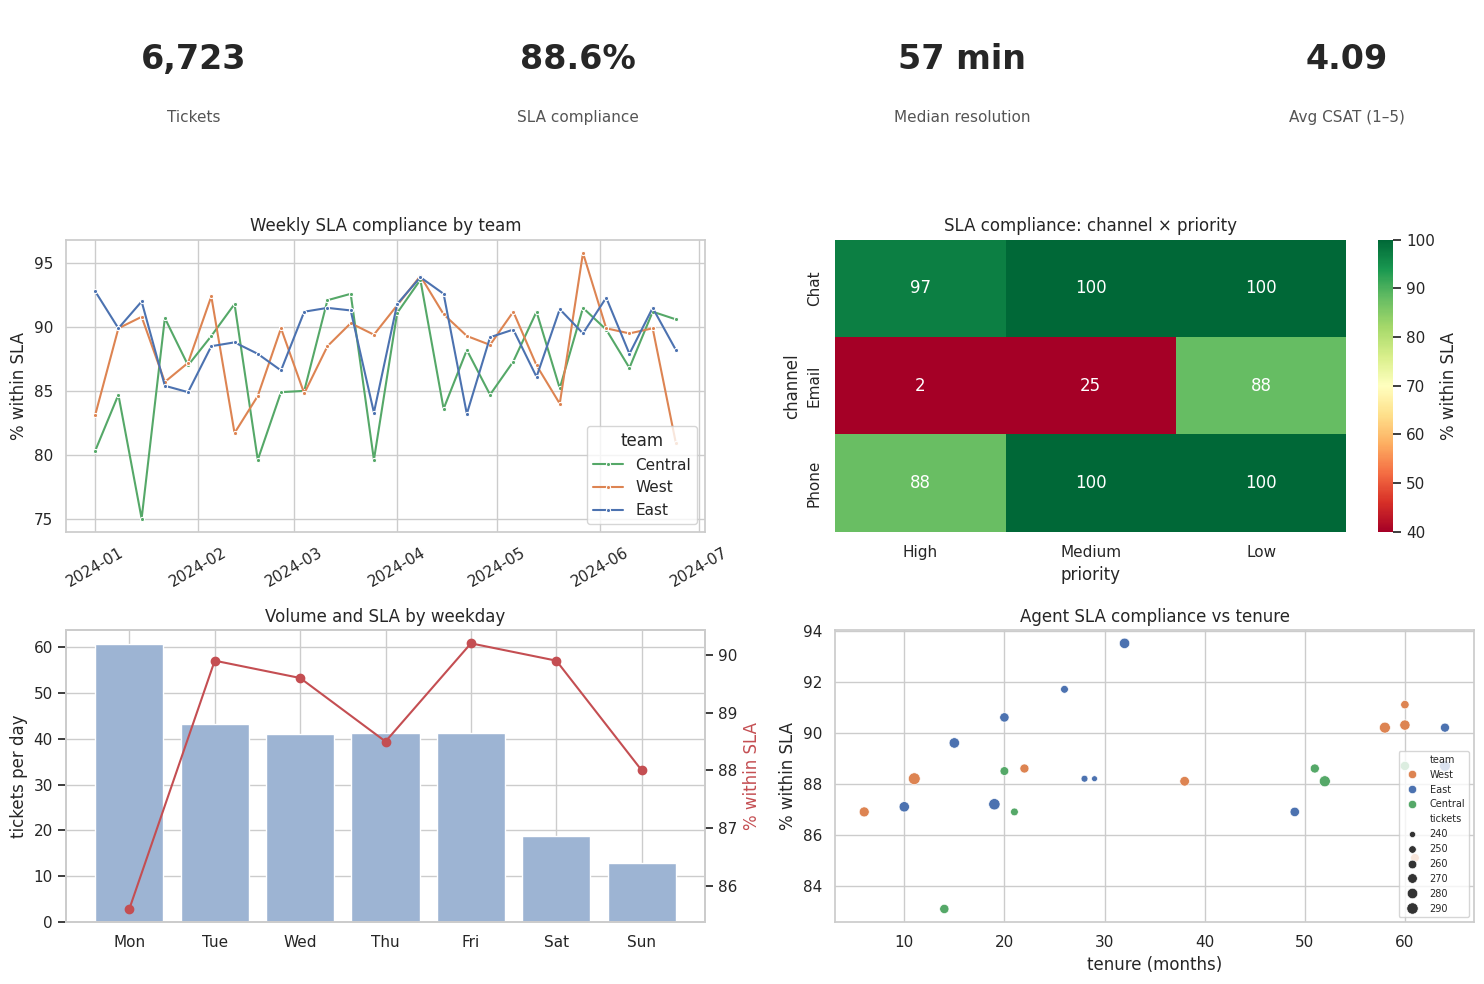

In [5]:
k = gold["kpi_summary"].iloc[0]
fig = plt.figure(figsize=(15, 10)); gs = fig.add_gridspec(3, 4, height_ratios=[0.45, 1, 1])
tiles = [("Tickets", f"{int(k.tickets):,}"), ("SLA compliance", f"{k.sla_compliance_pct:.1f}%"),
         ("Median resolution", f"{int(k.median_resolution_min)} min"), ("Avg CSAT (1–5)", f"{k.avg_csat:.2f}")]
for i, (lab, val) in enumerate(tiles):
    ax = fig.add_subplot(gs[0, i]); ax.axis("off")
    ax.text(0.5, 0.62, val, ha="center", va="center", fontsize=24, weight="bold"); ax.text(0.5, 0.15, lab, ha="center", fontsize=11, color="#555")

wk = gold["weekly_team"].sort_values("week_start")
ax = fig.add_subplot(gs[1, :2]); sns.lineplot(data=wk, x="week_start", y="sla_compliance_pct", hue="team", palette=TEAM_COLORS, ax=ax, marker="o", ms=3)
ax.set_title("Weekly SLA compliance by team"); ax.set_xlabel(""); ax.set_ylabel("% within SLA"); ax.tick_params(axis="x", rotation=30)

hm = gold["sla_by_channel_priority"].pivot(index="channel", columns="priority", values="sla_compliance_pct")[["High", "Medium", "Low"]]
ax = fig.add_subplot(gs[1, 2:]); sns.heatmap(hm, annot=True, fmt=".0f", cmap="RdYlGn", vmin=40, vmax=100, ax=ax, cbar_kws={"label": "% within SLA"})
ax.set_title("SLA compliance: channel × priority")

wl = gold["weekday_load"].assign(order=lambda x: (x.dow + 5) % 7).sort_values("order")  # Monday first
ax = fig.add_subplot(gs[2, :2]); ax2 = ax.twinx()
ax.bar(wl.weekday, wl.tickets_per_day, color="#9DB4D3"); ax2.plot(wl.weekday, wl.sla_compliance_pct, color="#C44E52", marker="o")
ax.set_ylabel("tickets per day"); ax2.set_ylabel("% within SLA", color="#C44E52"); ax.set_title("Volume and SLA by weekday"); ax2.grid(False)

sc = gold["agent_scorecard"]
ax = fig.add_subplot(gs[2, 2:]); sns.scatterplot(data=sc, x="tenure_months", y="sla_compliance_pct", size="tickets", hue="team", palette=TEAM_COLORS, ax=ax, legend="brief")
ax.set_title("Agent SLA compliance vs tenure"); ax.set_xlabel("tenure (months)"); ax.set_ylabel("% within SLA"); ax.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.savefig("images/dashboard.png", dpi=110); plt.show()

## 5. Supporting tables

In [6]:
display(gold["csat_by_sla"])
display(gold["sla_by_channel_priority"].sort_values("sla_compliance_pct").head(5))
sc["tenure_band"] = pd.cut(sc.tenure_months, [0, 12, 24, 200], labels=["<1 yr", "1–2 yrs", "2+ yrs"])
display(sc.groupby("tenure_band", observed=True).agg(agents=("agent_id", "count"), sla_compliance_pct=("sla_compliance_pct", "mean"), median_resolution_min=("median_resolution_min", "median")).round(1))
display(wl[["weekday", "tickets_per_day", "sla_compliance_pct"]].round(1))

,sla_status,surveys,avg_csat,pct_satisfied
0,Within SLA,1801,4.20,80.8
1,SLA breached,218,3.17,36.7


,channel,priority,tickets,sla_compliance_pct,median_resolution_min
0,Email,High,177,1.7,202.0
4,Email,Medium,616,25.3,346.0
5,Phone,High,473,87.7,28.0
3,Email,Low,514,87.9,629.0
8,Chat,High,375,97.1,18.0


,agents,sla_compliance_pct,median_resolution_min
tenure_band,,,
<1 yr,3,87.4,73.0
1–2 yrs,7,87.8,58.0
2+ yrs,15,89.2,53.0


,weekday,tickets_per_day,sla_compliance_pct
1,Mon,60.6,85.6
6,Tue,43.1,89.9
3,Wed,41.0,89.6
2,Thu,41.2,88.5
0,Fri,41.2,90.2
4,Sat,18.7,89.9
5,Sun,12.8,88.0


## 6. Publish (Databricks only)
On Databricks the silver table is saved as a Delta table, and the gold views back a Databricks SQL dashboard.
Locally, the CSVs in `marts/` can be loaded straight into Power BI or Tableau.

In [7]:
if "DATABRICKS_RUNTIME_VERSION" in os.environ:
    spark.sql("CREATE DATABASE IF NOT EXISTS credit_union")
    dashboard_df.write.format("delta").mode("overwrite").saveAsTable("credit_union.dashboard_data")
else:
    print("local run: marts written to", sorted(os.listdir("marts")))

local run: marts written to ['agent_scorecard.csv', 'csat_by_sla.csv', 'kpi_summary.csv', 'sla_by_channel_priority.csv', 'weekday_load.csv', 'weekly_team.csv']
